# Lecture 1 - Homework: Solution Bluesky

## Part 1: Setup and Data Collection

### 1.1 Install and Import Required Libraries

First, let's install and import all necessary libraries.

In [1]:
# Install required packages (run once)
# Uncomment the line below if packages are not installed
# !pip install atproto networkx matplotlib numpy pandas

In [1]:
# Import libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# For Bluesky
from atproto import Client as BskyClient

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


### 1.2 Bluesky Authentication

**Setup:** Fill in your Bluesky credentials in `config.py`: Add your BLUESKY_HANDLE and BLUESKY_APP_PASSWORD

In [2]:
# BLUESKY AUTHENTICATION
try:
    from config import BLUESKY_HANDLE, BLUESKY_APP_PASSWORD
    
    client = BskyClient()
    client.login(BLUESKY_HANDLE, BLUESKY_APP_PASSWORD)
    print(f"✓ Authenticated as {BLUESKY_HANDLE}")
    
except ImportError:
    print("⚠ config.py not found. Please copy config_template.py to config.py and add your credentials.")
    raise
except Exception as e:
    print(f"⚠ Authentication failed: {e}")
    raise

print("✓ Bluesky client initialized")

✓ Authenticated as n-marckx.bsky.social
✓ Bluesky client initialized


### 1.3 Data Collection

#### Step 1: Define Target Accounts

In [3]:
# Define the accounts to analyze
# Use these example accounts or replace with your own
my_name = "dirkvandenpoel.bsky.social"  # Main account
follower_names = ["stevenrogge.bsky.social", "profgeorgebert.bsky.social"]  # Two followers

# To use your own account, replace the values above:
# my_name = "yourusername.bsky.social"
# follower_names = ["follower1.bsky.social", "follower2.bsky.social"]

# Get the profile of the main account
account = client.app.bsky.actor.get_profile({'actor': my_name})

print(f"Account: {account.display_name}")
print(f"Handle: {account.handle}")
print(f"Followers: {account.followers_count}")

Account: Dirk Van den Poel 
Handle: dirkvandenpoel.bsky.social
Followers: 380


#### Step 2: Get First-Degree Followers

Collect followers of the main account using the Bluesky API.

In [4]:
def get_followers(client, handle, limit=100):
    """Get followers for a given handle using Bluesky API."""
    followers = []
    cursor = None
    
    while len(followers) < limit:
        try:
            # Use the Bluesky API method
            params = {'actor': handle, 'limit': min(100, limit - len(followers))}
            if cursor:
                params['cursor'] = cursor
            
            response = client.app.bsky.graph.get_followers(params)
            followers.extend(response.followers)
            
            if not response.cursor or len(followers) >= limit:
                break
            cursor = response.cursor
        except Exception as e:
            print(f"Error fetching followers: {e}")
            break
    
    return followers[:limit]

# Get first-degree followers (limit to 100)
firstdegree = get_followers(client, account.handle, limit=100)
print(f"✓ Collected {len(firstdegree)} first-degree followers")

✓ Collected 100 first-degree followers


#### Step 3: Get Second-Degree Followers

Collect followers of the two selected follower accounts.

In [5]:
seconddegree = []
seconddegreefollowers = []

for follower_handle in follower_names:
    print(f"Scraping: {follower_handle}")
    try:
        # Get profile
        profile = client.app.bsky.actor.get_profile({'actor': follower_handle})
        seconddegree.append(profile)
        
        # Get their followers (limit to 50 each for efficiency)
        followers = get_followers(client, profile.handle, limit=50)
        seconddegreefollowers.append(followers)
        print(f"  → Collected {len(followers)} followers")
    except Exception as e:
        print(f"  → Error: {e}")

print(f"\n✓ Collected {len(seconddegreefollowers)} second-degree networks")

Scraping: stevenrogge.bsky.social
  → Collected 50 followers
Scraping: profgeorgebert.bsky.social
  → Collected 50 followers

✓ Collected 2 second-degree networks


## Part 2: Build Network Structure

### 2.1 Create Follower Dictionary

Organize the collected data into a dictionary structure.

In [6]:
# Combine all follower data
all_followers_list = seconddegreefollowers + [firstdegree]
all_accounts = [acc.handle for acc in seconddegree] + [account.handle]

# Create dictionary: {account_handle: [list of follower handles]}
followers_dict = {}

for i, acc_handle in enumerate(all_accounts):
    # Extract handles from follower objects
    follower_handles = [f.handle for f in all_followers_list[i]]
    # Clean handles (remove domain part for username)
    follower_handles = [h.split('.')[0] for h in follower_handles]
    followers_dict[acc_handle.split('.')[0]] = follower_handles

print(f"✓ Created follower dictionary with {len(followers_dict)} accounts")
print(f"Accounts: {list(followers_dict.keys())}")
for acc, followers in followers_dict.items():
    print(f"  {acc}: {len(followers)} followers")

✓ Created follower dictionary with 3 accounts
Accounts: ['stevenrogge', 'profgeorgebert', 'dirkvandenpoel']
  stevenrogge: 50 followers
  profgeorgebert: 50 followers
  dirkvandenpoel: 100 followers


### 2.2 Build Adjacency Matrix

Create an adjacency matrix from the follower relationships using a co-occurrence approach.

In [7]:
# Step 1: Get all unique followers
all_unique_followers = set()
for followers in followers_dict.values():
    all_unique_followers.update(followers)

all_unique_followers = sorted(list(all_unique_followers))
print(f"Total unique followers: {len(all_unique_followers)}")

Total unique followers: 198


In [8]:
# Step 2: Create binary incidence matrix
# Rows = our 3 accounts, Columns = all unique followers
account_names = list(followers_dict.keys())
incidence_data = []

for account in account_names:
    row = [1 if follower in followers_dict[account] else 0 for follower in all_unique_followers]
    incidence_data.append(row)

incidence_matrix = pd.DataFrame(
    incidence_data,
    index=account_names,
    columns=all_unique_followers
)

print(f"Incidence matrix shape: {incidence_matrix.shape}")
print(f"  {incidence_matrix.shape[0]} accounts × {incidence_matrix.shape[1]} followers")

Incidence matrix shape: (3, 198)
  3 accounts × 198 followers


In [9]:
# Step 3: Compute adjacency matrix: A = I^T × I
adjacency_matrix = incidence_matrix.T @ incidence_matrix

print(f"Adjacency matrix shape: {adjacency_matrix.shape}")
print(f"Connection values range from {adjacency_matrix.values.min()} to {adjacency_matrix.values.max()}")
print(f"\nInterpretation:")
print(f"  Value 0: No common accounts followed")
print(f"  Value 1: Follow 1 common account")
print(f"  Value 2: Follow 2 common accounts")
print(f"  Value 3: Follow all 3 accounts (strong connection)")

Adjacency matrix shape: (198, 198)
Connection values range from 0 to 2

Interpretation:
  Value 0: No common accounts followed
  Value 1: Follow 1 common account
  Value 2: Follow 2 common accounts
  Value 3: Follow all 3 accounts (strong connection)


### 2.3 Create Network Graph

Build a NetworkX graph from the adjacency matrix.

In [10]:
# Create NetworkX graph from adjacency matrix
G_full = nx.from_pandas_adjacency(adjacency_matrix)

# Remove self-loops
G_full.remove_edges_from(nx.selfloop_edges(G_full))

# Remove edges with weight 0
edges_to_remove = [(u, v) for u, v, w in G_full.edges(data='weight') if w == 0]
G_full.remove_edges_from(edges_to_remove)

# Use largest connected component
if not nx.is_connected(G_full):
    largest_cc = max(nx.connected_components(G_full), key=len)
    G = G_full.subgraph(largest_cc).copy()
    print(f"Using largest connected component")
else:
    G = G_full.copy()

print(f"✓ Network created:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.4f}")

Using largest connected component
✓ Network created:
  Nodes: 148
  Edges: 6174
  Density: 0.5676



## Part 3: Network Visualization

### 3.1 Calculate Centrality Measures

In [11]:
# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Find top nodes by each measure
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 nodes by Degree Centrality:")
for node, score in top_degree:
    print(f"  {node}: {score:.4f}")

print("\nTop 5 nodes by Betweenness Centrality:")
for node, score in top_betweenness[:5]:
    print(f"  {node}: {score:.4f}")

print("\nTop 5 nodes by Closeness Centrality:")
for node, score in top_closeness:
    print(f"  {node}: {score:.4f}")

print("\n✓ Centrality measures calculated")

Top 5 nodes by Degree Centrality:
  encodenetwork: 1.0000
  matthbogaert: 1.0000
  4040rec: 0.6735
  abinashmishra018: 0.6735
  amberbrouckaert: 0.6735

Top 5 nodes by Betweenness Centrality:
  encodenetwork: 0.2192
  matthbogaert: 0.2192
  4040rec: 0.0000
  abinashmishra018: 0.0000
  albeperego: 0.0000

Top 5 nodes by Closeness Centrality:
  encodenetwork: 1.0000
  matthbogaert: 1.0000
  4040rec: 0.7538
  abinashmishra018: 0.7538
  amberbrouckaert: 0.7538

✓ Centrality measures calculated


### 3.2 Visualize the Network

Create a network visualization with nodes colored by centrality.

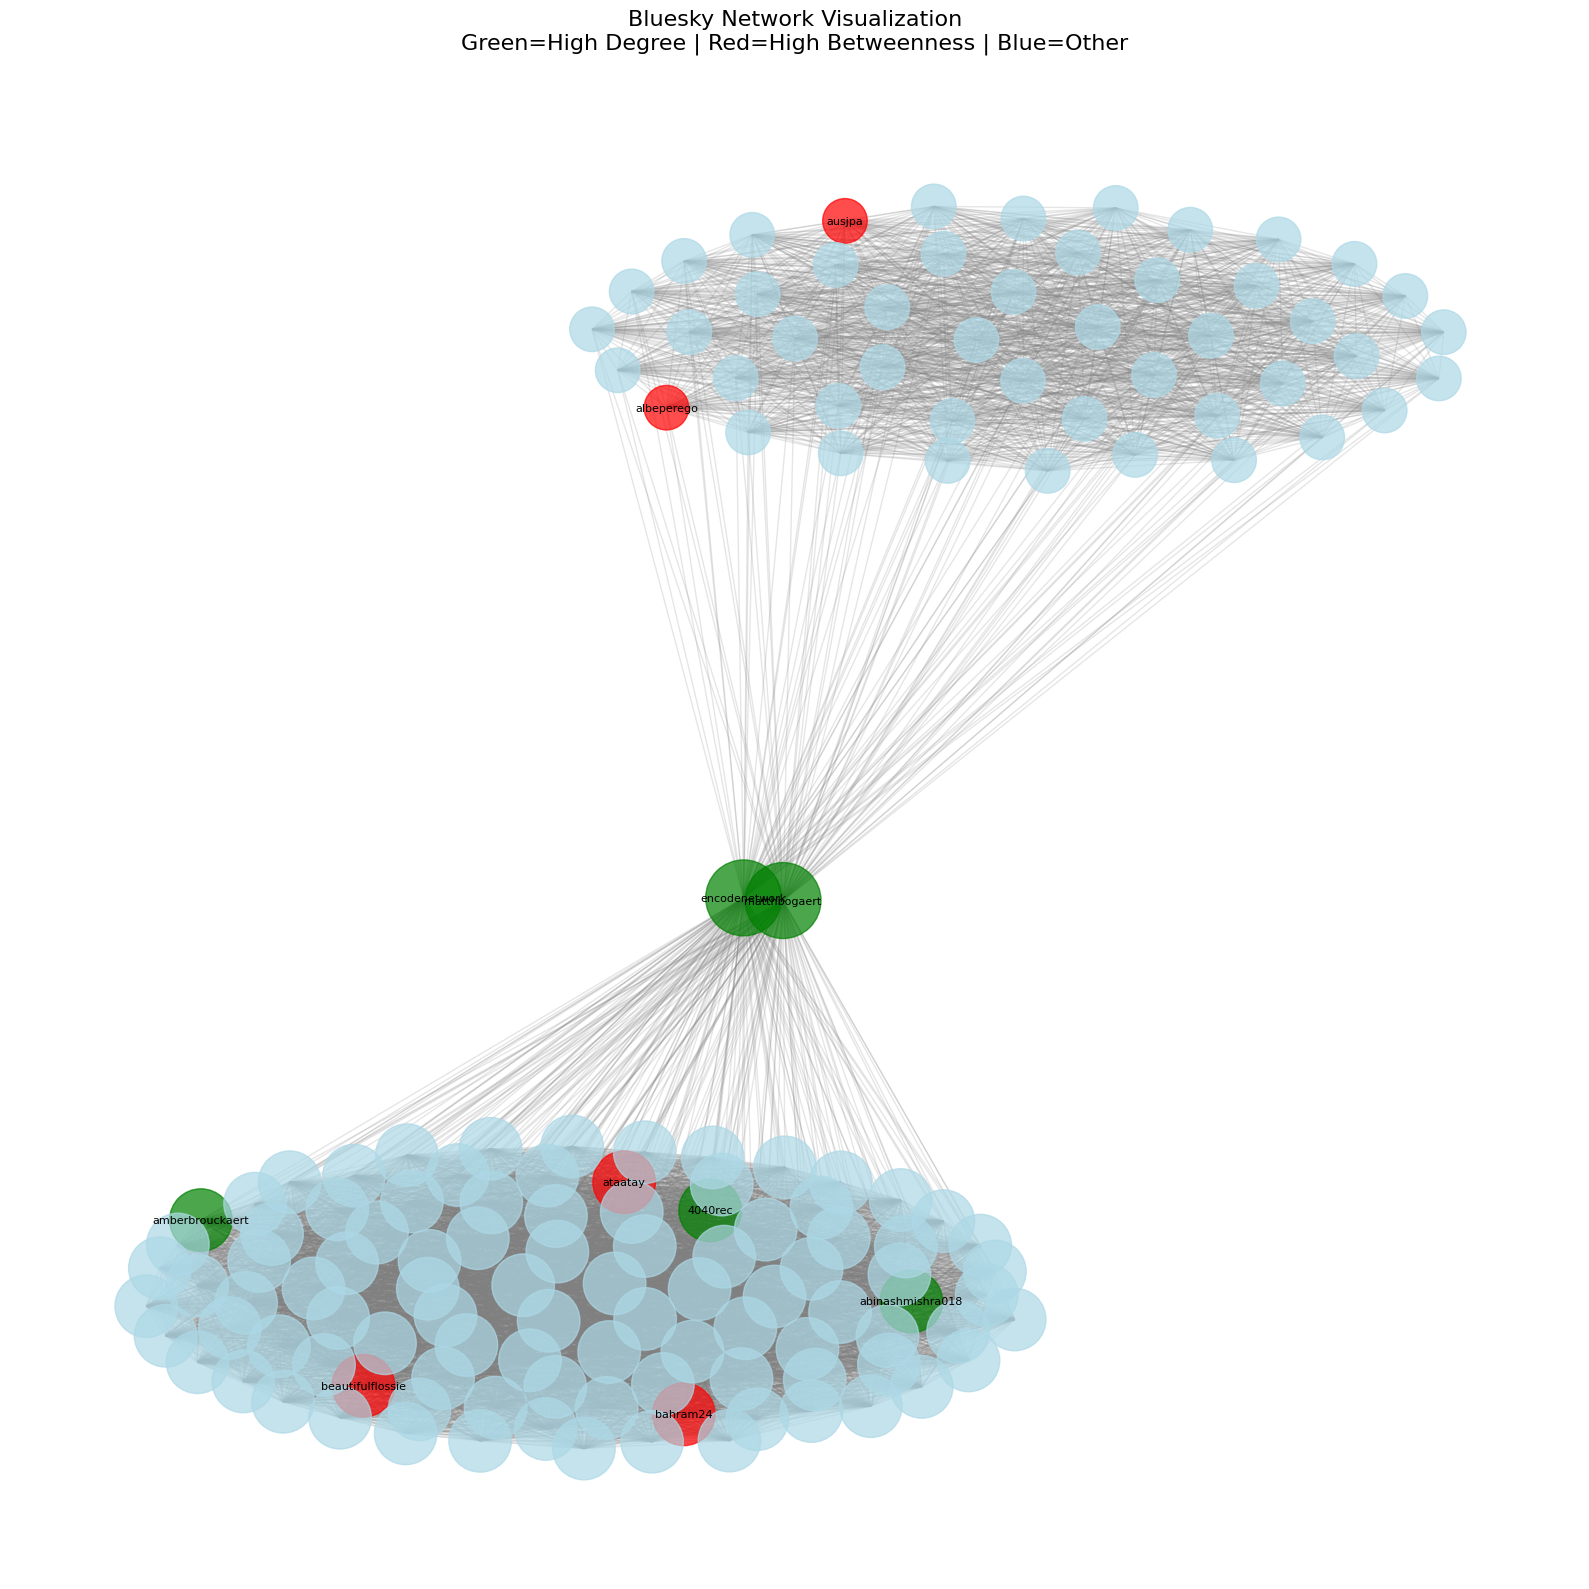

✓ Visualization complete


In [12]:
# Set up the plot
plt.figure(figsize=(16, 16))

# Calculate layout
pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

# Get top nodes
top_degree_nodes = set([node for node, _ in top_degree])
top_betweenness_nodes = set([node for node, _ in top_betweenness])
betweenness_only = top_betweenness_nodes - top_degree_nodes

# Color nodes based on centrality
node_colors = []
for node in G.nodes():
    if node in top_degree_nodes:
        node_colors.append('green')
    elif node in betweenness_only:
        node_colors.append('red')
    else:
        node_colors.append('lightblue')

# Node sizes based on degree
node_sizes = [G.degree(node) * 20 + 50 for node in G.nodes()]

# Draw the network
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.2, edge_color='gray')

# Label top nodes
labels = {node: node for node in G.nodes() if node in top_degree_nodes or node in betweenness_only}
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Bluesky Network Visualization\nGreen=High Degree | Red=High Betweenness | Blue=Other", 
          fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## Part 4: Network Analysis

### 4.1 Basic Network Statistics

In [13]:
# Calculate network statistics
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / n_nodes

print("=== Basic Network Statistics ===")
print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Network density: {density:.4f}")
print(f"Average degree: {avg_degree:.2f}")

=== Basic Network Statistics ===
Number of nodes: 148
Number of edges: 6174
Network density: 0.5676
Average degree: 83.43


### 4.2 Degree Distribution

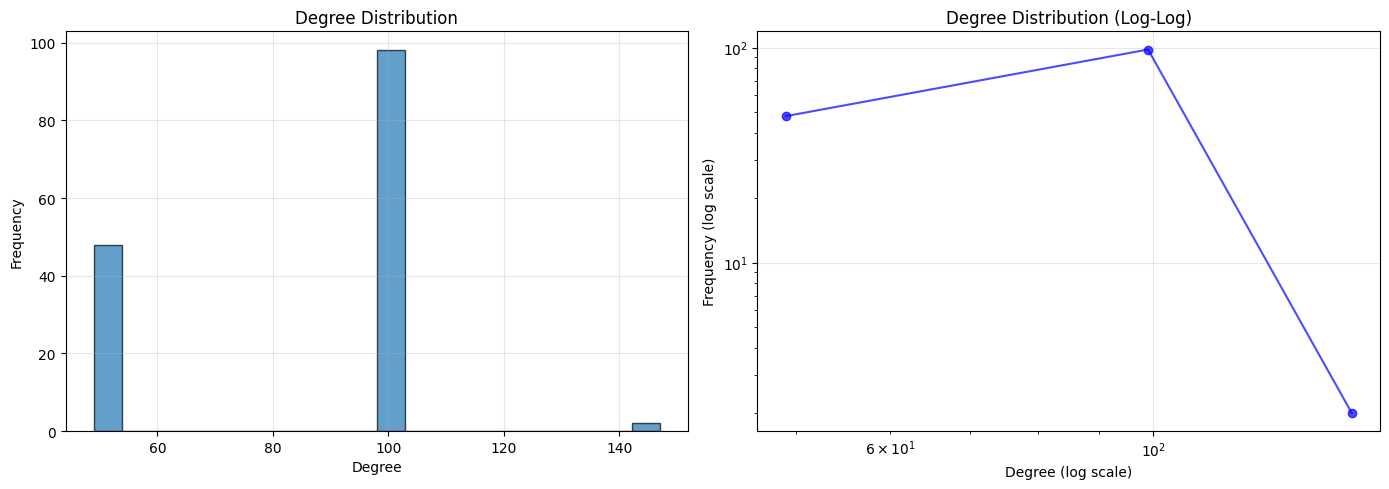

Degree statistics:
  Min degree: 49
  Max degree: 147
  Median degree: 99.0


In [14]:
# Analyze degree distribution
degrees = [G.degree(node) for node in G.nodes()]
degree_counts = Counter(degrees)

# Plot degree distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(degrees, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Degree Distribution')
axes[0].grid(True, alpha=0.3)

# Log-log plot
degree_values = sorted(degree_counts.keys())
frequencies = [degree_counts[d] for d in degree_values]
axes[1].loglog(degree_values, frequencies, 'bo-', alpha=0.7)
axes[1].set_xlabel('Degree (log scale)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Degree Distribution (Log-Log)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Degree statistics:")
print(f"  Min degree: {min(degrees)}")
print(f"  Max degree: {max(degrees)}")
print(f"  Median degree: {np.median(degrees):.1f}")

### 4.3 Connectivity and Components

In [15]:
# Analyze connectivity
is_connected = nx.is_connected(G)
n_components = nx.number_connected_components(G)
components = list(nx.connected_components(G))
largest_component_size = len(max(components, key=len))

print("=== Connectivity ===")
print(f"Is connected: {is_connected}")
print(f"Number of components: {n_components}")
print(f"Largest component size: {largest_component_size}")

if is_connected:
    diameter = nx.diameter(G)
    avg_path_length = nx.average_shortest_path_length(G)
    print(f"Diameter: {diameter}")
    print(f"Average path length: {avg_path_length:.2f}")

=== Connectivity ===
Is connected: True
Number of components: 1
Largest component size: 148
Diameter: 2
Average path length: 1.43


### 4.4 Clustering

In [16]:
# Analyze clustering
avg_clustering = nx.average_clustering(G)

print("=== Clustering ===")
print(f"Average clustering coefficient: {avg_clustering:.4f}")
print(f"\nInterpretation: This measures how much nodes tend to cluster together.")
print(f"  0 = No clustering (tree-like structure)")
print(f"  1 = Perfect clustering (all neighbors connected)")

=== Clustering ===
Average clustering coefficient: 0.9941

Interpretation: This measures how much nodes tend to cluster together.
  0 = No clustering (tree-like structure)
  1 = Perfect clustering (all neighbors connected)


### 4.5 Key Influencers Analysis

=== Top 10 Influencers (by Degree Centrality) ===
                    Degree  Betweenness  Closeness
encodenetwork     1.000000     0.219178   1.000000
matthbogaert      1.000000     0.219178   1.000000
4040rec           0.673469     0.000000   0.753846
abinashmishra018  0.673469     0.000000   0.753846
amberbrouckaert   0.673469     0.000000   0.753846
ataatay           0.673469     0.000000   0.753846
bahram24          0.673469     0.000000   0.753846
beautifulflossie  0.673469     0.000000   0.753846
begumbektas       0.673469     0.000000   0.753846
brigittevalade1   0.673469     0.000000   0.753846


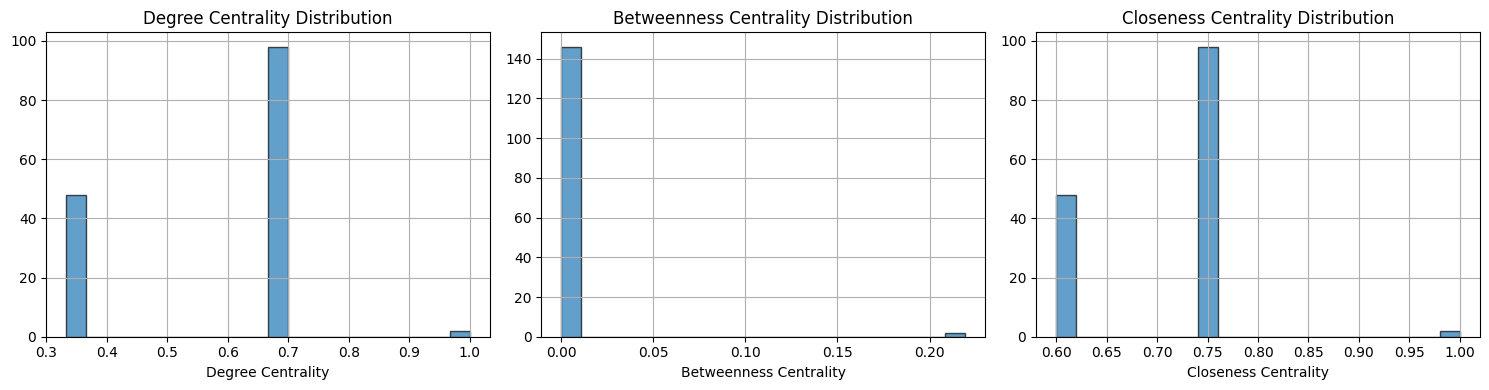

In [17]:
# Compare centrality measures
centrality_df = pd.DataFrame({
    'Degree': degree_centrality,
    'Betweenness': betweenness_centrality,
    'Closeness': closeness_centrality
})

# Get top nodes
top_by_degree = centrality_df.nlargest(10, 'Degree')

print("=== Top 10 Influencers (by Degree Centrality) ===")
print(top_by_degree.to_string())

# Visualize centrality distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

centrality_df['Degree'].hist(bins=20, ax=axes[0], edgecolor='black', alpha=0.7)
axes[0].set_title('Degree Centrality Distribution')
axes[0].set_xlabel('Degree Centrality')

centrality_df['Betweenness'].hist(bins=20, ax=axes[1], edgecolor='black', alpha=0.7)
axes[1].set_title('Betweenness Centrality Distribution')
axes[1].set_xlabel('Betweenness Centrality')

centrality_df['Closeness'].hist(bins=20, ax=axes[2], edgecolor='black', alpha=0.7)
axes[2].set_title('Closeness Centrality Distribution')
axes[2].set_xlabel('Closeness Centrality')

plt.tight_layout()
plt.show()

### 4.6 Compare Top Nodes Across Metrics

In [18]:
# Get top 10 by each metric
top_nodes_data = []

for metric in ['Degree', 'Betweenness', 'Closeness']:
    top_10 = centrality_df.nlargest(10, metric).index.tolist()
    top_nodes_data.append(top_10)

# Create comparison dataframe
top_nodes_df = pd.DataFrame({
    'Top by Degree': top_nodes_data[0],
    'Top by Betweenness': top_nodes_data[1],
    'Top by Closeness': top_nodes_data[2]
})

print("=== Comparison of Top 10 Nodes by Different Metrics ===")
print(top_nodes_df.to_string(index=False))

=== Comparison of Top 10 Nodes by Different Metrics ===
   Top by Degree Top by Betweenness Top by Closeness
   encodenetwork      encodenetwork    encodenetwork
    matthbogaert       matthbogaert     matthbogaert
         4040rec            4040rec          4040rec
abinashmishra018   abinashmishra018 abinashmishra018
 amberbrouckaert         albeperego  amberbrouckaert
         ataatay    amberbrouckaert          ataatay
        bahram24            ataatay         bahram24
beautifulflossie             ausjpa beautifulflossie
     begumbektas           bahram24      begumbektas
 brigittevalade1   beautifulflossie  brigittevalade1


## Summary and Insights

### Key Findings

This notebook analyzed a Bluesky follower network with the following results:

1. **Network Size**: The network contains followers from 3 seed accounts
2. **Density**: Shows how interconnected the network is
3. **Key Influencers**: Identified by degree, betweenness, and closeness centrality
4. **Clustering**: Measures community structure and local connectivity

### Reflection Questions

1. **Network Structure**: Is your network densely or sparsely connected? What does this tell you?
2. **Influential Nodes**: Are the top nodes by degree centrality the same as those with high betweenness?
3. **Practical Implications**: Which nodes would you target to spread information quickly?
4. **Limitations**: What are the limitations of this data collection approach?
